# Attention Heads Clustering Analysis

This notebook mirrors the **`run_analyze`** pipeline from `analyze.py` step by step. It performs:

1. **Feature matrix** – Load or build per-head features from circuit discovery data; add derived clustering features (induction, position, bio, etc.).
2. **KMeans clustering** – Fit KMeans on scaled features, assign cluster labels from centroid extremes (Induction, Relative Position, AA-biased).
3. **Cluster summaries** – Normalized (scaled) and original mean summaries per cluster.
4. **Welch ANOVA** – Test which features differ significantly across clusters.
5. **Outliers** – Identify repeat-focus outliers via IQR.
6. **UMAP visualization** – 2D projection with convex hulls by cluster.
7. **Clustering results** – Per-head table with node_name, layer, head, cluster (e.g. Induction Heads, Relative Position Heads, AA-biased Heads).

**Before you run**: In the Config cell, choose `model_type` (e.g. `"esm3"` or `"esm-c"`) to specify which PLM’s attention heads to cluster. You can also set `counterfactual_type` and `repeat_type` to match your dataset and features.

**Prerequisite**: Run `run_collect_features.py` first to generate `features.csv`. Results are displayed inline (no CSV/plot saving).

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Find repo root (dir containing plms_repeats_circuits package) by walking up from cwd
REPO_ROOT = Path(os.getcwd()).resolve()
for _ in range(10):
    pkg = REPO_ROOT / "plms_repeats_circuits"
    if pkg.is_dir() and (pkg / "__init__.py").exists():
        break
    parent = REPO_ROOT.parent
    if REPO_ROOT == parent:
        raise RuntimeError(
            "plms_repeats_circuits not found. cd to the plms-repeats-circuits repo and run again."
        )
    REPO_ROOT = parent

sys.path.insert(0, str(REPO_ROOT))
script_dir = REPO_ROOT / "scripts" / "attention_heads_clustering_experiments"
sys.path.insert(0, str(script_dir))

from plms_repeats_circuits.utils.counterfactuals_config import find_file_for_method
from analyze import (
    filter_dataset_single_example_per_protein,
    compute_amino_acid_frequencies,
    build_per_head_feature_matrix,
    add_derived_clustering_features,
    fit_kmeans_and_assign_clusters,
    assign_cluster_labels_from_centroids,
    compute_cluster_summaries,
    run_welch_anova_per_feature,
    identify_repeat_focus_outliers,
    plot_inertia_silhouette_curves,
    plot_umap_cluster_visualization,
)

# Config (matches run_analyze defaults)
model_type = "esm3"  # or "esm-c"
counterfactual_type = "blosum"
repeat_type = "approximate"  # identical | approximate | synthetic
n_clusters = 3
clustering_cols = [
    "induction_score",
    "mean_attn_to_bos_eos",
    "pos_score",
    "attn_entropy",
    "contribution_to_residual_stream_mean_tokens",
    "vocab_entropy",
    "bio_jsd",
    "diff_corrupted_clean",
    "repeat_focus",
]

datasets_root = REPO_ROOT / "datasets"
results_root = REPO_ROOT / "results"
out_dir = results_root / "attention_heads_clustering" / model_type / counterfactual_type
out_dir.mkdir(parents=True, exist_ok=True)

# Resolve paths (dataset dir for circuit discovery, not results/circuit_discovery)
circuit_discovery_dataset_dir = datasets_root / repeat_type / model_type / "circuit_discovery"
dataset_path = find_file_for_method(
    counterfactual_type, circuit_discovery_dataset_dir, kind="main", ext="csv"
)
if dataset_path is None:
    raise FileNotFoundError(
        f"No dataset for '{counterfactual_type}' in {circuit_discovery_dataset_dir}"
    )

features_path = out_dir / "collected_features.csv"
aggregated_features_path = out_dir / "aggregated_features.csv"
if not features_path.exists():
    raise FileNotFoundError(f"Features not found: {features_path}. Run collect_features first.")

print(f"Dataset: {dataset_path}")
print(f"Features: {features_path}")
print(f"Aggregated features cache: {aggregated_features_path}")

Dataset: /home/galkesten/plms-repeats-circuits/datasets/approximate/esm3/circuit_discovery/approximate_counterfactual_blosum.csv
Features: /home/galkesten/plms-repeats-circuits/results/attention_heads_clustering/esm3/blosum/collected_features.csv
Aggregated features cache: /home/galkesten/plms-repeats-circuits/results/attention_heads_clustering/esm3/blosum/aggregated_features.csv


## 1. Build feature matrix

If `aggregated_features.csv` exists, load it directly. Otherwise:
- **Filter dataset**: Keep one example per (cluster_id, rep_id) pair.
- **Amino acid frequencies**: Compute from dataset for bio score.
- **Per-head feature matrix**: Aggregate features from `features.csv` over proteins.
- **Derived features**: Add induction_score, pos_score, bio_jsd, mean_attn_to_bos_eos, etc.

In [2]:
if aggregated_features_path.exists():
    feat_df = pd.read_csv(aggregated_features_path)
    print(f"Loaded cached aggregated features: {len(feat_df)} heads")
else:
    dataset_df, excluded = filter_dataset_single_example_per_protein(str(dataset_path))
    print(f"Dataset: {len(dataset_df)} rows, excluded {len(excluded)} names")

    aa_freq = compute_amino_acid_frequencies(dataset_df)
    feat_df = build_per_head_feature_matrix(
        str(features_path), dataset_df, excluded, aa_freq
    )
    feat_df = add_derived_clustering_features(feat_df)
    print(f"Feature matrix: {len(feat_df)} heads")

Loaded cached aggregated features: 149 heads


## 2. KMeans clustering and cluster label assignment

- **Fit KMeans** on scaled features (StandardScaler) with k=2..10 for metrics, then fit at `n_clusters`.
- **Inertia & silhouette curves**: Elbow and silhouette vs k (displayed inline).
- **Assign cluster labels** from centroid extremes: max induction → "Induction", max pos_score → "Relative Position", max bio_jsd → "AA-biased".

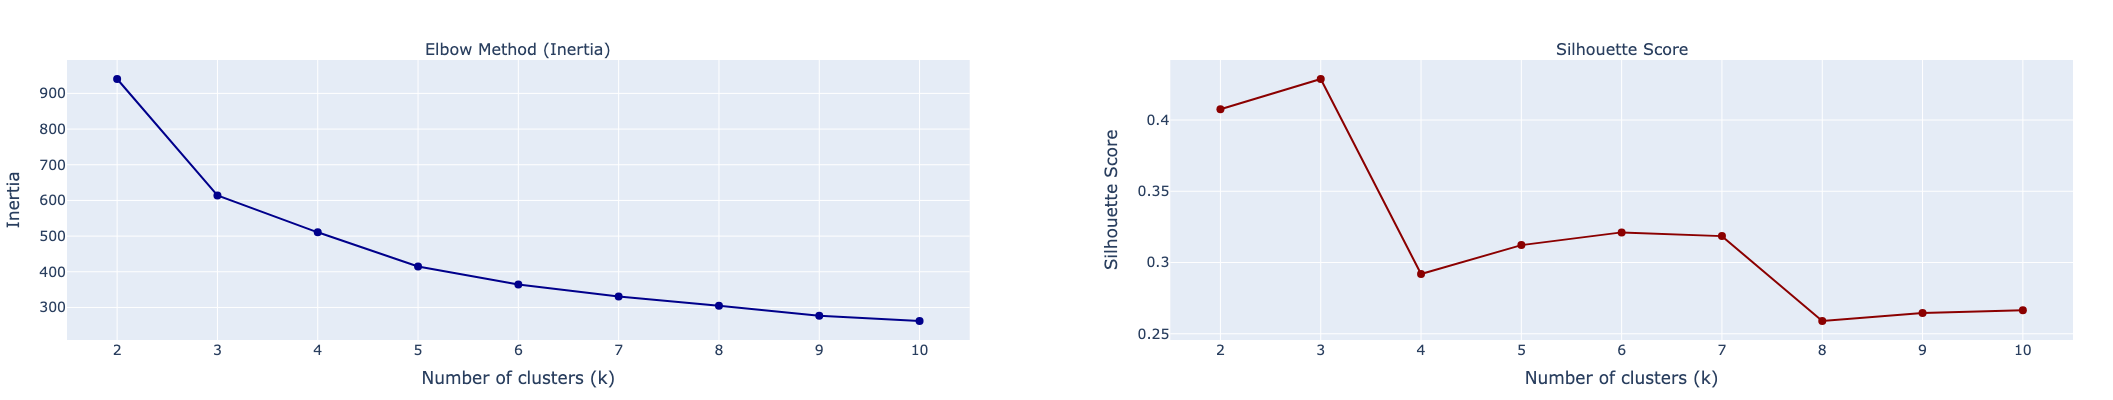

,k,inertia,silhouette
0,2,940.339477,0.407579
1,3,614.147982,0.428796
2,4,510.601663,0.291911
3,5,414.632766,0.312224
4,6,364.462157,0.321158
5,7,330.924102,0.318535
6,8,305.050107,0.258972
7,9,276.892247,0.264673
8,10,262.035920,0.266467


In [3]:
labels, k_metrics, X_scaled = fit_kmeans_and_assign_clusters(
    feat_df, clustering_cols, k=n_clusters
)
plot_inertia_silhouette_curves(
    k_metrics,
    out_dir / "inertia_silhouette_curves",
    display_inline=True,
)

feat_df = assign_cluster_labels_from_centroids(feat_df, labels, clustering_cols)

# KMeans metrics (k=2..10)
display(k_metrics)

## 3. Cluster summaries

Per-cluster means of clustering features: **normalized_summary** (scaled) and **orig_summary** (original scale). Includes cluster size.

In [ ]:
norm_summary, orig_summary = compute_cluster_summaries(
    feat_df, labels, clustering_cols, X_scaled
)
display(norm_summary)
display(orig_summary)

,size,induction_score,mean_attn_to_bos_eos,pos_score,attn_entropy,contribution_to_residual_stream_mean_tokens,vocab_entropy,bio_jsd,diff_corrupted_clean,repeat_focus
cluster,,,,,,,,,,
0,99,-0.250207,-0.378045,0.568008,-0.534239,0.143807,-0.076450,-0.455559,-0.466867,-0.280810
1,7,4.223892,0.955950,-2.244852,0.294621,1.444754,-2.648185,-0.491497,3.042651,3.300053
2,43,-0.111553,0.714763,-0.942297,1.182030,-0.566282,0.607112,1.128856,0.579564,0.109298


,size,induction_score,mean_attn_to_bos_eos,pos_score,attn_entropy,contribution_to_residual_stream_mean_tokens,vocab_entropy,bio_jsd,diff_corrupted_clean,repeat_focus
cluster,,,,,,,,,,
0,99,0.026035,0.005776,0.992422,0.323840,0.287858,0.478021,0.043260,0.080100,-0.001678
1,7,0.650045,0.051457,0.666529,0.537010,0.462120,0.152556,0.041335,0.761108,1.003358
2,43,0.045374,0.043198,0.817441,0.765239,0.192742,0.564529,0.128150,0.283156,0.107813


## 4. Welch ANOVA per feature

One-way ANOVA (Welch, unequal variances) for each clustering feature across clusters. Low p-value indicates the feature differs significantly across cluster labels.

In [ ]:
anova_df = run_welch_anova_per_feature(
    feat_df, "cluster_label", clustering_cols
)
display(anova_df)

,feature,Welch F-stat,p-value
0,induction_score,40.894018,1.313103e-06
1,mean_attn_to_bos_eos,13.954794,4.622872e-04
2,pos_score,107.321591,3.010452e-09
3,attn_entropy,174.272075,1.311319e-12
4,contribution_to_residual_stream_mean_tokens,21.673646,2.688235e-05
5,vocab_entropy,35.683211,1.981832e-06
6,bio_jsd,37.857104,2.855906e-08
7,diff_corrupted_clean,55.635483,1.766226e-07
8,repeat_focus,46.188747,5.966552e-07


## 5. Repeat-focus outliers

Heads with repeat_focus above IQR threshold (q3 + 1.5×IQR).

In [ ]:
outliers = identify_repeat_focus_outliers(feat_df)
display(outliers[["node_name", "repeat_focus", "cluster_label"]].head(20) if len(outliers) > 0 else pd.DataFrame())

,node_name,repeat_focus,cluster_label
19,a23.h5,0.816091,Induction Heads
20,a23.h23,0.667427,Induction Heads
22,a24.h16,0.628178,AA-biased Heads
23,a24.h19,0.355772,AA-biased Heads
30,a26.h19,0.701462,AA-biased Heads
31,a27.h5,0.618378,AA-biased Heads
38,a28.h13,0.744994,Induction Heads
39,a29.h1,1.076351,Induction Heads
43,a31.h8,0.562150,AA-biased Heads
49,a33.h23,0.417850,AA-biased Heads


## 6. UMAP visualization

2D projection with convex hulls by cluster (colorblind palette).

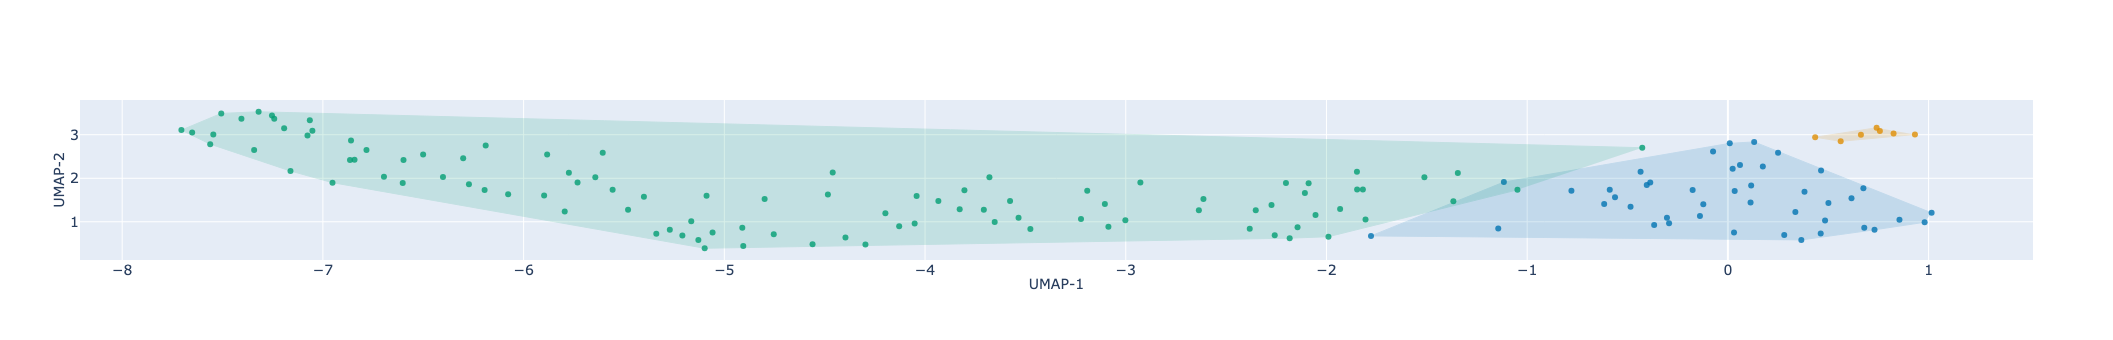

In [ ]:
plot_umap_cluster_visualization(
    feat_df, clustering_cols, "cluster_label",
    out_dir / "cluster_visualization",
    display_inline=True,
    n_neighbors=30
)

## 7. Clustering results

Per-head table with `node_name`, `layer`, `head`, `cluster` (e.g. Induction Heads, Relative Position Heads, AA-biased Heads).

In [ ]:
clustering_results = feat_df[["node_name", "layer", "head"]].copy()
clustering_results["cluster"] = feat_df["cluster_label"]
display(clustering_results)

,node_name,layer,head,cluster
0,a0.h4,0,4,AA-biased Heads
1,a0.h7,0,7,Relative Position Heads
2,a0.h17,0,17,Relative Position Heads
3,a3.h9,3,9,Relative Position Heads
4,a3.h12,3,12,Relative Position Heads
...,...,...,...,...
144,a47.h18,47,18,AA-biased Heads
145,a47.h19,47,19,AA-biased Heads
146,a47.h20,47,20,AA-biased Heads
147,a47.h21,47,21,Relative Position Heads
